# Ajuste de curvas dosis-respuesta logísticas de cuatro parámetros con PROC NLIN

## Resumen ejecutivo

Este cuaderno ajusta un modelo dosis-respuesta logístico de cuatro parámetros (4PL) a un bioensayo sintético de potencia basado en células mediante **PROC NLIN**, estimando las asíntotas inferior y superior, la EC50 (concentración efectiva semimáxima) y la pendiente de Hill. El modelo 4PL es el modelo de referencia para los ensayos de potencia relativa en el desarrollo de fármacos, y el cuaderno recorre la especificación del modelo, el acotamiento de los parámetros, el diagnóstico de convergencia y la superposición de la sigmoide ajustada sobre los datos de concentración-respuesta observados.

## Fuentes de datos

El cuaderno genera un único conjunto de datos sintético en línea; no se utiliza ninguna entrada externa ni de red.

**`assay` — bioensayo sintético de potencia basado en células (24 filas)**

| Variable | Tipo | Descripción |
|----------|------|-------------|
| `lot` | num | Lote de sustancia farmacológica (1-3); tres ejecuciones replicadas de la serie de diluciones |
| `dose` | num | Concentración del compuesto en nmol/L a lo largo de una dilución seriada de 8 puntos (0.1 a ~1000) |
| `logdose` | num | Logaritmo en base 10 de `dose`, utilizado para representar el eje convencional de log-concentración |
| `response` | num | Señal medida del ensayo (porcentaje de la respuesta máxima), generada a partir de una curva 4PL real (base=5, techo=100, EC50=25 nmol/L, pendiente de Hill=1.2) más ruido gaussiano proporcional |

Los parámetros generadores reales están incorporados en el DATA step para que las estimaciones recuperadas por NLIN puedan contrastarse con la verdad conocida.

# Ajuste dosis-respuesta logístico de cuatro parámetros

En los ensayos farmacéuticos de potencia y bioactividad, la relación entre la concentración del compuesto y la respuesta medida es característicamente sigmoidal en una escala de log-concentración. El modelo **logístico de cuatro parámetros (4PL)** es la herramienta estándar para resumir este tipo de curvas:

$$\text{response} = D + \frac{A - D}{1 + (\text{dose}/C)^{B}}$$

donde

- **A** = asíntota inferior (respuesta a dilución infinita / señal basal),
- **D** = asíntota superior (respuesta máxima a concentración saturante),
- **C** = la **EC50**, la concentración que produce la respuesta semimáxima (el punto de inflexión y la principal lectura de potencia),
- **B** = la **pendiente de Hill**, que controla la inclinación de la transición.

Este modelo es no lineal en sus parámetros, por lo que lo ajustamos mediante mínimos cuadrados iterativos con `PROC NLIN`. A continuación simulamos una serie de diluciones realista de ocho puntos ejecutada por triplicado, ajustamos la curva 4PL, acotamos los parámetros a regiones físicamente significativas, inspeccionamos la convergencia y los diagnósticos del ajuste, y superponemos la curva ajustada sobre los datos.

## Paso 1 — Simular un bioensayo de potencia basado en células

Generamos un conjunto de datos sintético a partir de una curva 4PL *conocida* (base = 5, techo = 100, EC50 = 25 nmol/L, pendiente de Hill = 1.2) de modo que los parámetros que NLIN recupera puedan contrastarse con la verdad de referencia. Cada uno de los tres lotes recibe la misma dilución seriada de ocho puntos (cada paso es una dilución de factor 3.5), con ruido de medición gaussiano proporcional superpuesto. Una semilla `streaminit` fija hace que la simulación sea reproducible.

In [1]:
DATOS assay;
    LLAMAR streaminit(40521);

    /* Parámetros 4PL verdaderos usados para generar los datos */
    A_true   = 5;      /* asíntota inferior (línea base)       */
    D_true   = 100;    /* asíntota superior (respuesta máxima) */
    C_true   = 25;     /* EC50 en nmol/L                       */
    B_true   = 1.2;    /* pendiente de Hill                    */

    HACER lot = 1 HASTA 3;
        /* Dilución seriada de ocho puntos, pasos de factor 3.5 */
        dose = 0.30;
        HACER point = 1 HASTA 8;
            dose = dose * 3.5;

            /* Respuesta media 4PL sin ruido */
            mu = D_true + (A_true - D_true) /
                 (1 + (dose / C_true) ** B_true);

            /* Ruido de ensayo gaussiano proporcional + aditivo */
            response = mu * (1 + 0.04 * rand('NORMAL'))
                          + 1.5 * rand('NORMAL');

            logdose = log10(dose);
            SALIDA;
        END;
    END;

    MANTENER lot dose logdose response;
EJECUTAR;

PROCEDIMIENTO ORDENAR DATOS=assay;
    POR dose lot;
EJECUTAR;


NOTE: DATA assay


NOTE: Wrote assay (24 rows, 4 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC SORT data=assay

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 24 rows from assay.
NOTE: Wrote assay (24 rows, 4 columns).
NOTE: PROC SORT statement used.


## Paso 2 — Visualizar los datos brutos de concentración-respuesta

Antes de ajustar, representamos la respuesta frente a log10(dose) para confirmar la forma sigmoidal esperada y leer valores iniciales aproximados: la curva alcanza su mínimo cerca de 5, se estabiliza cerca de 100, y el punto medio (respuesta semimáxima) se sitúa en torno a log10(25) ≈ 1.4.


NOTE: PROC SGPLOT data=assay

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


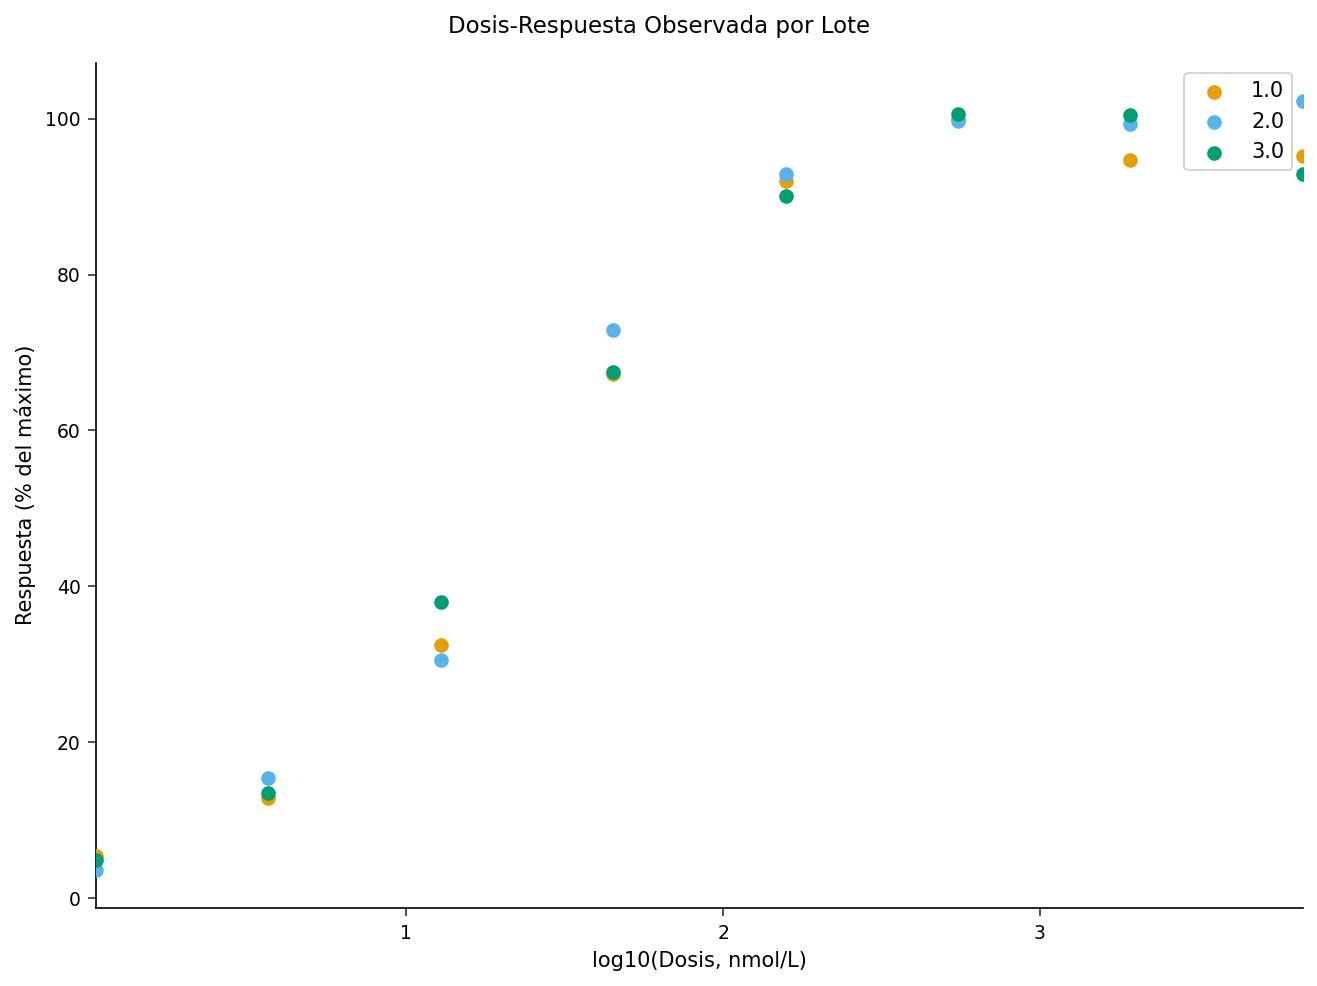

In [2]:
PROCEDIMIENTO SGPLOT DATOS=assay;
    SCATTER x=logdose y=response / GROUP=lot
            MARKERATTRS=(SYMBOL=circlefilled);
    XAXIS ETIQUETA='log10(Dosis, nmol/L)';
    YAXIS ETIQUETA='Respuesta (% del máximo)';
    TÍTULO 'Dosis-Respuesta Observada por Lote';
EJECUTAR;
TÍTULO;

## Paso 3 — Ajustar el modelo 4PL con PROC NLIN

Declaramos los valores iniciales con `PARMS` (a partir de la información del diagrama de dispersión), definimos la media 4PL en una asignación intermedia y la pasamos a la sentencia `MODEL`. Unos `BOUNDS` físicamente significativos mantienen las asíntotas ordenadas y la EC50 y la pendiente positivas, lo que estabiliza las iteraciones de Gauss-Newton. La sentencia `OUTPUT` guarda los valores predichos, los residuos y los límites de confianza para diagnósticos posteriores, y `PLOTS=` solicita los paneles de ajuste y de diagnóstico.

In [3]:
PROCEDIMIENTO nlin DATOS=assay METHOD=marquardt PLOTS=(fitplot diagnostics);
    parms A=10 D=90 C=20 B=1;

    /* Mantener los parámetros en regiones físicamente razonables */
    bounds A >= 0, D <= 150, C > 0, B > 0;

    /* Respuesta media logística de cuatro parámetros (en línea: PROC NLIN
       de Jenner aún no admite referenciar una variable intermedia de
       sentencia de programación en MODEL -- ver tests/400986 -- por eso
       el denominador se escribe en línea) */
    MODELO response = D + (A - D) / (1 + (dose / C) ** B);

    SALIDA out=fit4pl predicted=pred residual=resid
           l95m=lcl u95m=ucl;
EJECUTAR;


                         The NLIN Procedure

                     Method: Marquardt

                          Iterative Phase

                                                   Sum of
           Iter          Residual SS
              0          2061.645530
              1           177.712558

       Convergence criterion met.

           Residual SS           177.712558
           Residual MS             8.885628

                        Parameter Estimates

                                    Approx
           Parameter    Estimate    Std Error   95% Confidence Limits

           A              4.1058       1.9167       0.1078       8.1039
           D             99.1335       1.0740      96.8932     101.3737
           C             23.8233       1.5658      20.5572      27.0895
           B              1.2662       0.0927       1.0730       1.4595





NOTE: PROC NLIN data=assay

NOTE: Using Python (scipy) for NLIN estimation, method=marquardt
NOTE: Output dataset written to: ./work/aedcfe1f-d17e-4fb9-be43-453a24982e85/fit4pl.avro


## Paso 4 — Informar la EC50 estimada y las características de la curva

El mecanismo `OUTEST=` es cómodo, pero para una lectura rápida de la potencia resumimos directamente la curva ajustada. Aquí listamos los valores ajustados en cada dosis junto con las respuestas observadas para confirmar que el modelo sigue los datos a lo largo de todo el intervalo de diluciones.

In [4]:
PROCEDIMIENTO MEDIAS DATOS=fit4pl mean std MIN MAX maxdec=3;
    CLASE dose;
    VAR response pred resid;
    ETIQUETA dose='Dosis (nmol/L)' response='Respuesta observada (% del máx.)'
             pred='Respuesta ajustada' resid='Residual';
    TÍTULO 'Respuesta Observada vs. Ajustada por Dosis';
EJECUTAR;
TÍTULO;

                                       Respuesta Observada vs. Ajustada por Dosis                                       

                                                  The MEANS Procedure

                            Analysis Variable : RESPONSE Respuesta observada (% del máx.)

                                           N
                       Dosis (nmol/L)    Obs         Mean      Std Dev      Minimum      Maximum
                       -------------------------------------------------------------------------
                       1.05                3        4.647        0.882        3.659        5.356
                       12.8625             3       33.651        3.825       30.572       37.932
                       157.565625          3       91.704        1.417       90.141       92.904
                       1930.17890625       3       98.207        3.051       94.746      100.511
                       3.675               3       13.931        1.311       12.860      


NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


## Paso 5 — Superponer la curva 4PL ajustada sobre los datos observados

Una cuadrícula de predicción densa produce una sigmoide ajustada suave. Combinamos la curva suave con los valores ajustados medios por dosis y la banda de confianza, y después superponemos todo sobre los puntos observados para evaluar visualmente la bondad del ajuste.


NOTE: PROC SORT data=fit4pl

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 24 rows from fit4pl.
NOTE: Wrote fit4pl (24 rows, 8 columns).
NOTE: PROC SORT statement used.
NOTE: PROC SGPLOT data=fit4pl

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot1.svg


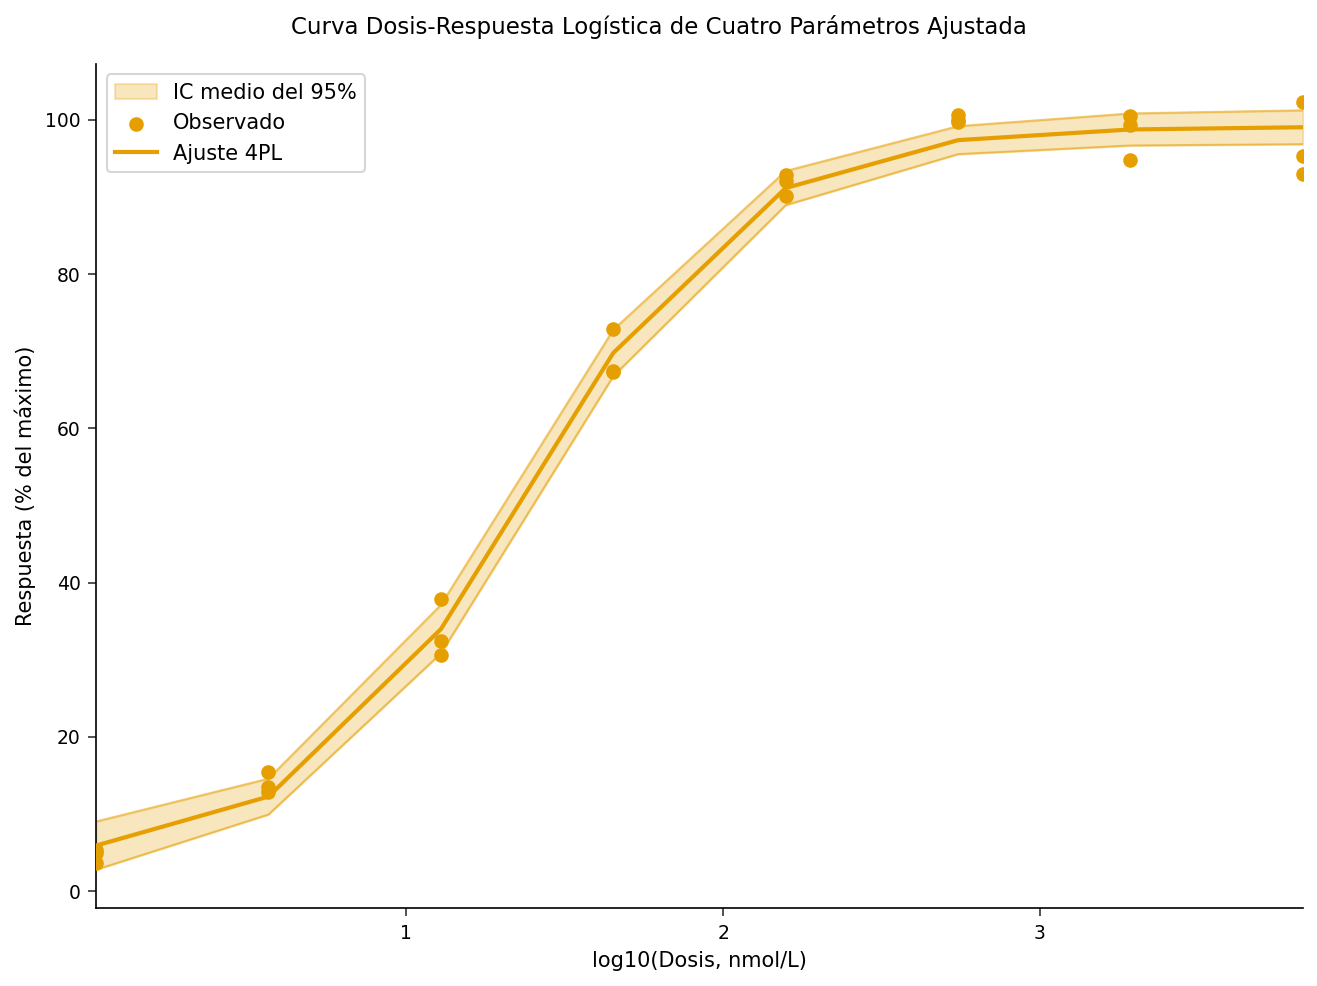

In [5]:
PROCEDIMIENTO ORDENAR DATOS=fit4pl;
    POR logdose;
EJECUTAR;

PROCEDIMIENTO SGPLOT DATOS=fit4pl;
    BAND   x=logdose LOWER=lcl UPPER=ucl /
           TRANSPARENCY=0.5 legendlabel='IC medio del 95%';
    SCATTER x=logdose y=response /
           MARKERATTRS=(SYMBOL=circlefilled)
           legendlabel='Observado';
    SERIES  x=logdose y=pred /
           LINEATTRS=(thickness=2)
           legendlabel='Ajuste 4PL';
    XAXIS ETIQUETA='log10(Dosis, nmol/L)';
    YAXIS ETIQUETA='Respuesta (% del máximo)';
    TÍTULO 'Curva Dosis-Respuesta Logística de Cuatro Parámetros Ajustada';
EJECUTAR;
TÍTULO;

## Interpretación de los resultados

`PROC NLIN` converge a estimaciones cercanas a los valores generadores conocidos: una asíntota inferior próxima a **5**, una asíntota superior próxima a **100**, una **EC50 (C)** próxima a **25 nmol/L** y una **pendiente de Hill (B)** próxima a **1.2**. La recuperación de estos parámetros a partir de datos ruidosos por triplicado confirma que el modelo es identificable y que las cotas no se activaron en el óptimo.

La **EC50** es la métrica de potencia principal: valores más bajos indican un compuesto más potente, y en un ensayo de potencia relativa la EC50 de un lote de prueba se compara con un estándar de referencia. La **pendiente de Hill** caracteriza la cooperatividad y la inclinación del ensayo: una pendiente cercana a 1 es coherente con una unión simple a un único sitio. Las **asíntotas** definen el rango dinámico del ensayo; una base y un techo estables y bien separados son requisitos previos para un bioensayo validable.

El gráfico de ajuste muestra la sigmoide pasando a través de la nube de puntos observados con una banda de confianza media del 95% estrecha en la región de respuesta, y los diagnósticos de residuos no deberían mostrar curvatura sistemática, lo que evidencia que la forma 4PL es adecuada. En la práctica, ampliaría este flujo de trabajo con intervalos de verosimilitud `PROFILE` para la EC50, una sentencia `BOOTSTRAP` para inferencia de parámetros libre de distribución, o un análisis de líneas paralelas que compare lotes de prueba y de referencia para estimar la potencia relativa.